Philip Fowler
2025 13 07
A notebook to investigate methods for comparing different datasets

# Load libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import plotly.express as px
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import lag_plot
from scipy.optimize import linear_sum_assignment
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx
import h5py


In [2]:
# Define some constants
filename = 'IFNeuron-stuff/test-3000-ms.hdf5'

In [3]:
with h5py.File(filename, 'r') as f:
    # List all keys in the file
    print(list(f.keys()))

    # Check the type and shape of each key
    for key in f.keys():
        data_item = f[key]
        print(f"{key}: type={type(data_item)}", end='')
        if isinstance(data_item, h5py.Dataset):
            print(f", shape={data_item.shape}")
        else:
            print()


['trial_0', 'trial_1', 'trial_2', 'trial_3', 'trial_4']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>
trial_2: type=<class 'h5py._hl.group.Group'>
trial_3: type=<class 'h5py._hl.group.Group'>
trial_4: type=<class 'h5py._hl.group.Group'>


In [4]:
with h5py.File(filename, 'r') as f:
    for trial_name in f.keys():
        if 'trial' in trial_name.lower():
            trial_group = f[trial_name]
            print(f"Keys in {trial_name} group:", list(trial_group.keys()))
            for name, item in trial_group.items():
                if isinstance(item, h5py.Dataset):
                    print(f"Dataset '{name}' in {trial_name} shape:", item.shape)
                else:
                    print(f"'{name}' in {trial_name} is a group, not a dataset.")


Keys in trial_0 group: ['data']
Dataset 'data' in trial_0 shape: (3000, 11)
Keys in trial_1 group: ['data']
Dataset 'data' in trial_1 shape: (3000, 11)
Keys in trial_2 group: ['data']
Dataset 'data' in trial_2 shape: (3000, 11)
Keys in trial_3 group: ['data']
Dataset 'data' in trial_3 shape: (3000, 11)
Keys in trial_4 group: ['data']
Dataset 'data' in trial_4 shape: (3000, 11)


In [5]:
with h5py.File(filename, 'r') as f:
    for trial_name in f.keys():
        if trial_name.startswith('trial_'):
            trial_group = f[trial_name]
            for name, item in trial_group.items():
                if isinstance(item, h5py.Dataset):
                    data = item[()]
                    if data.ndim == 2:
                        columns = [f'neuron{i+1}' for i in range(data.shape[1])]
                        df = pd.DataFrame(data, columns=columns)
                    else:
                        df = pd.DataFrame(data)
                    globals()[f"{trial_name.replace('_', '')}_df"] = df

                    new_columns = ['time']
                    for i in range(1, (len(columns))//2 + 1):
                        new_columns.append(f'neuron{i}_spike')
                        new_columns.append(f'neuron{i}_mempot')
                    df.columns = new_columns[:df.shape[1]]

In [6]:
trial0_df.head()

,time,neuron1_spike,neuron1_mempot,neuron2_spike,neuron2_mempot,neuron3_spike,neuron3_mempot,neuron4_spike,neuron4_mempot,neuron5_spike,neuron5_mempot
0,0.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
1,1.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
2,2.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
3,3.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
4,4.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0


In [7]:
with h5py.File(filename, 'r') as f:
    trial_numbers = [
        int(name.split('_')[1])
        for name in f.keys()
        if name.startswith('trial_') and name.split('_')[1].isdigit()
    ]
    max_trial_num = max(trial_numbers)
    print(f"Highest trial number: {max_trial_num}")
    print(f"Total number of trials: {len(trial_numbers)}")

df_name = f"trial{max_trial_num}_df"
df_max_trial = globals()[df_name]
df_max_trial.head()

Highest trial number: 4
Total number of trials: 5


,time,neuron1_spike,neuron1_mempot,neuron2_spike,neuron2_mempot,neuron3_spike,neuron3_mempot,neuron4_spike,neuron4_mempot,neuron5_spike,neuron5_mempot
0,0.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
1,1.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
2,2.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
3,3.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0
4,4.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0,0.0,-60.0


In [8]:
all_trials = [trial0_df, trial1_df, trial2_df, trial3_df, trial4_df]
NUM_TRIALS = len(all_trials)
num_neurons = len([col for col in all_trials[0].columns if col.endswith('_spike')])

# Metrics

The first plot here is a raster plot to exampine what a single trial looks like.  

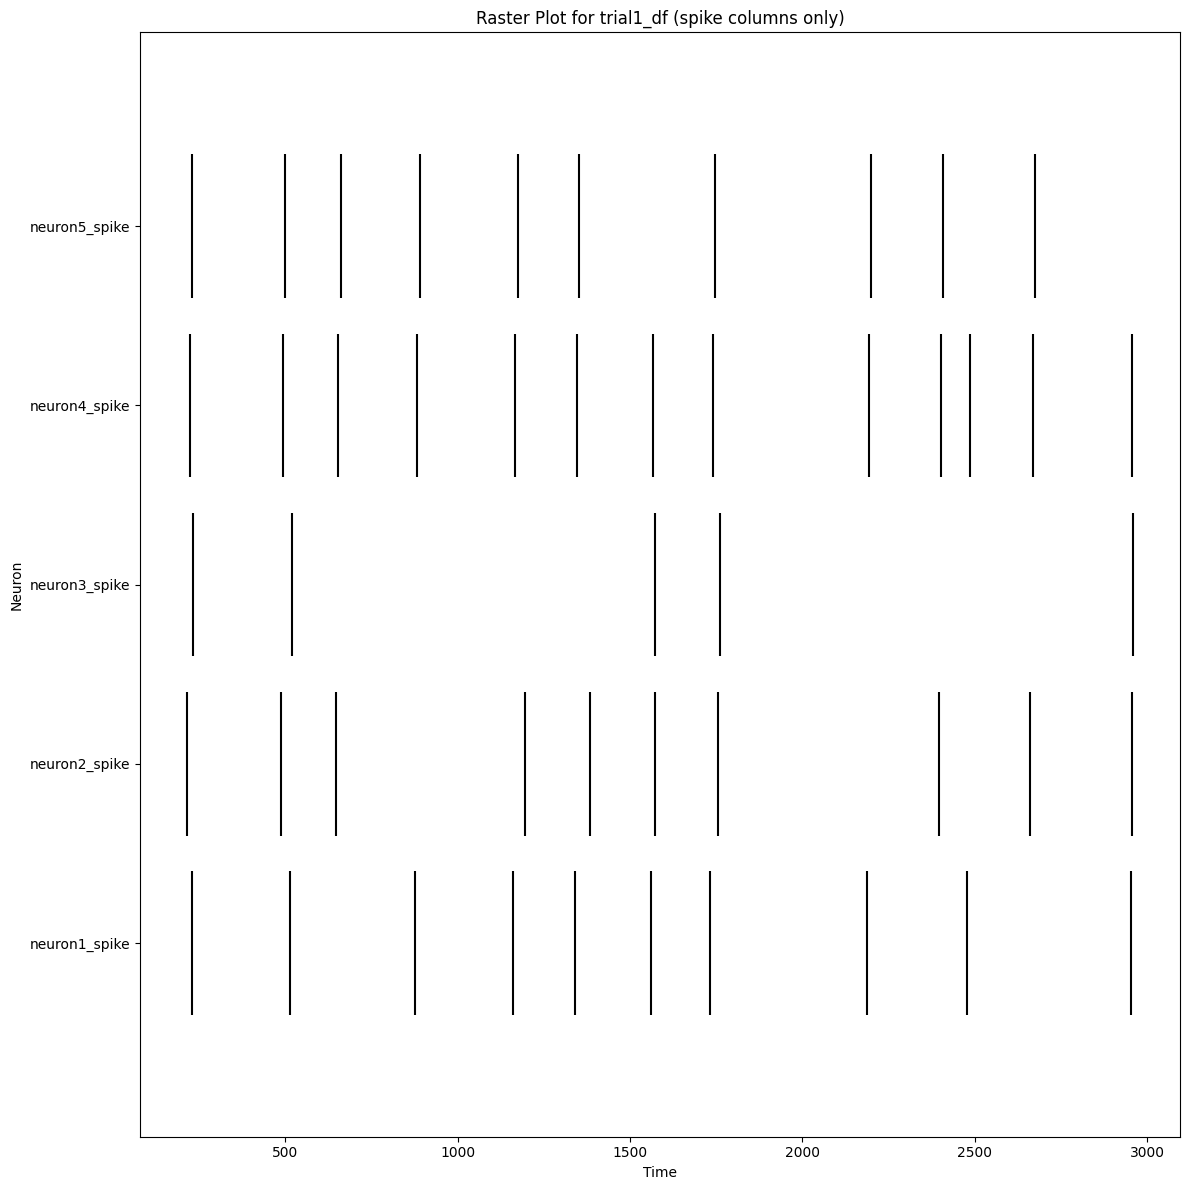

In [9]:
spike_columns = [col for col in trial0_df.columns if col.endswith('_spike')]
spike_times_per_neuron = [trial0_df.index[trial0_df[col] == 1].to_numpy() for col in spike_columns]

plt.figure(figsize=(12, 12))
plt.eventplot(spike_times_per_neuron, orientation='horizontal', colors='black', linelengths=0.8)
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot for trial1_df (spike columns only)')
plt.tight_layout()
plt.show()


This plot is also a raster plot to examine how the different trials compare to one another. 

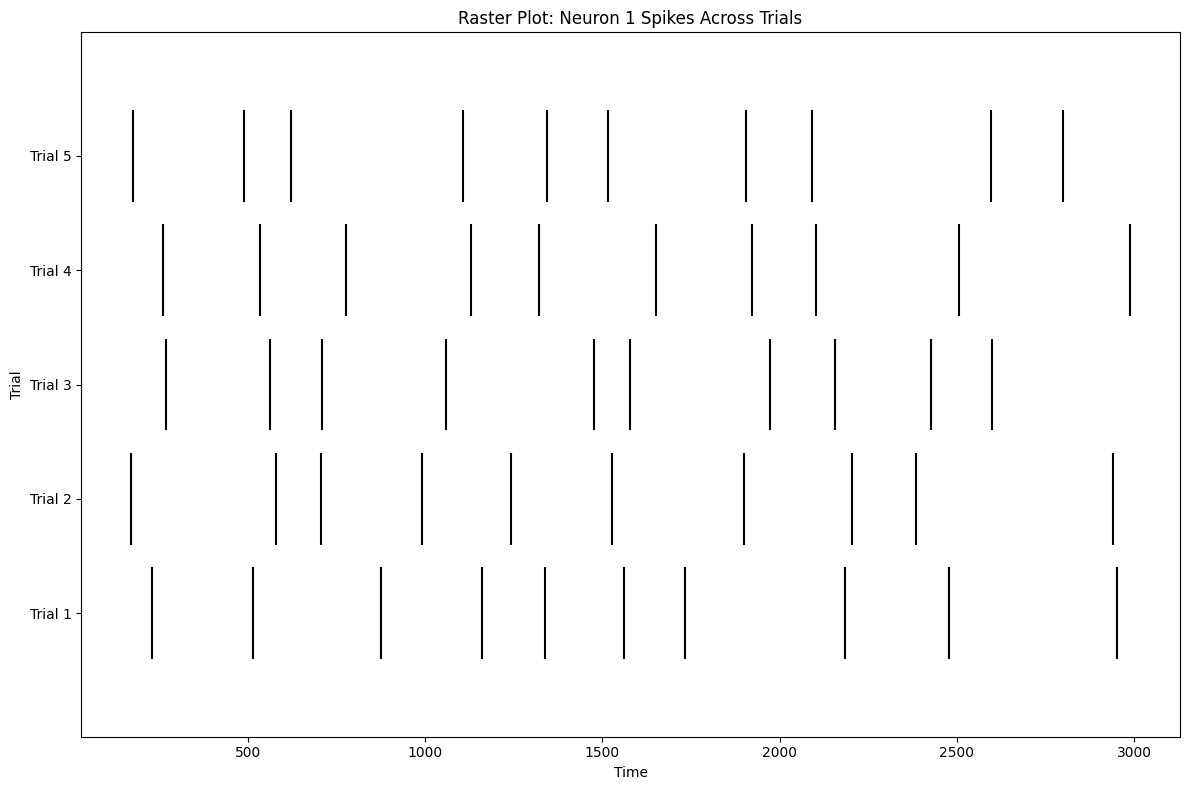

In [10]:
plt.figure(figsize=(12, 8))
neuron_idx = 0  
spike_times_per_trial = [
    trial_df.index[trial_df[spike_columns[neuron_idx]] == 1].to_numpy()
    for trial_df in [trial0_df, trial1_df, trial2_df, trial3_df, trial4_df]
]

plt.eventplot(spike_times_per_trial, orientation='horizontal', colors='black', linelengths=0.8)
plt.yticks(np.arange(len(spike_times_per_trial)), [f'Trial {i+1}' for i in range(len(spike_times_per_trial))])
plt.xlabel('Time')
plt.ylabel('Trial')
plt.title('Raster Plot: Neuron 1 Spikes Across Trials')
plt.tight_layout()
plt.show()

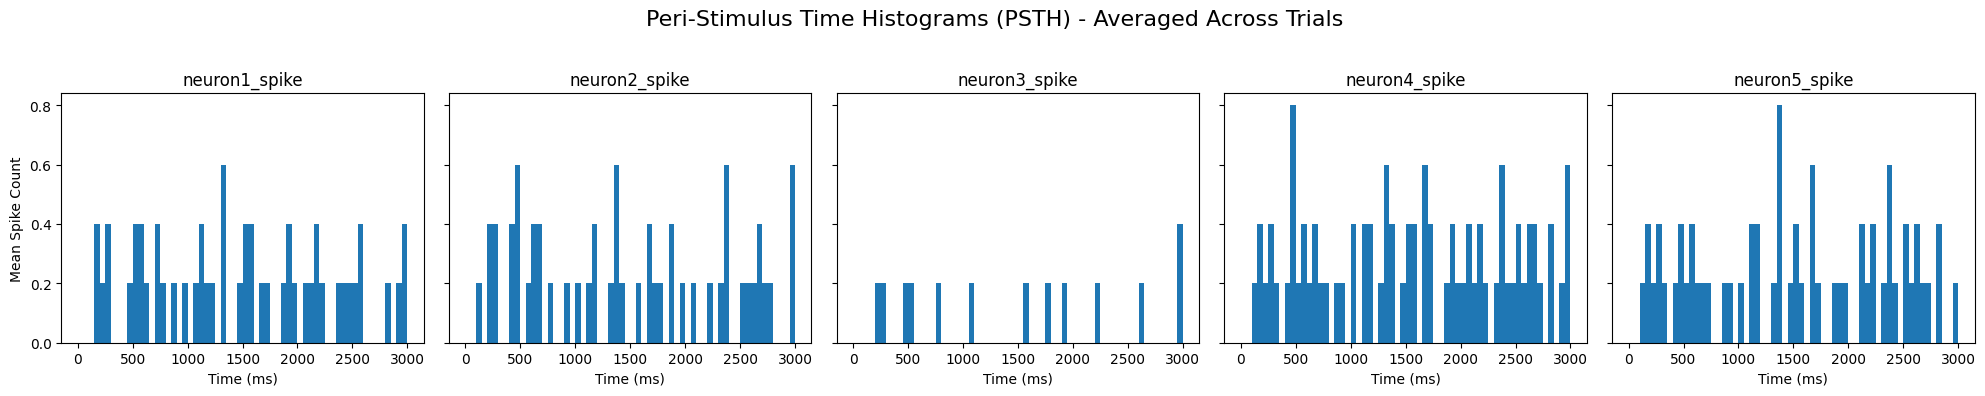

In [11]:
bin_size = 50
num_bins = all_trials[0].shape[0] // bin_size

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]

binned_spikes = np.zeros((len(all_trials), num_bins, num_neurons))
for t, trial_df in enumerate(all_trials):
    for n, col in enumerate(spike_columns):
        spikes = trial_df[col].values[:num_bins*bin_size]
        binned_spikes[t, :, n] = spikes.reshape(num_bins, bin_size).sum(axis=1)

mean_spike_counts = binned_spikes.mean(axis=0)
time_bins = np.arange(num_bins) * bin_size

fig, axes = plt.subplots(1, num_neurons, figsize=(4*num_neurons, 4), sharey=True)
if num_neurons == 1:
    axes = [axes]
for i, col in enumerate(spike_columns):
    axes[i].bar(time_bins, mean_spike_counts[:, i], width=bin_size, align='edge', color='tab:blue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Time (ms)')
    if i == 0:
        axes[i].set_ylabel('Mean Spike Count')
plt.suptitle('Peri-Stimulus Time Histograms (PSTH) - Averaged Across Trials', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Rate Based Metrics

Interspike Interval

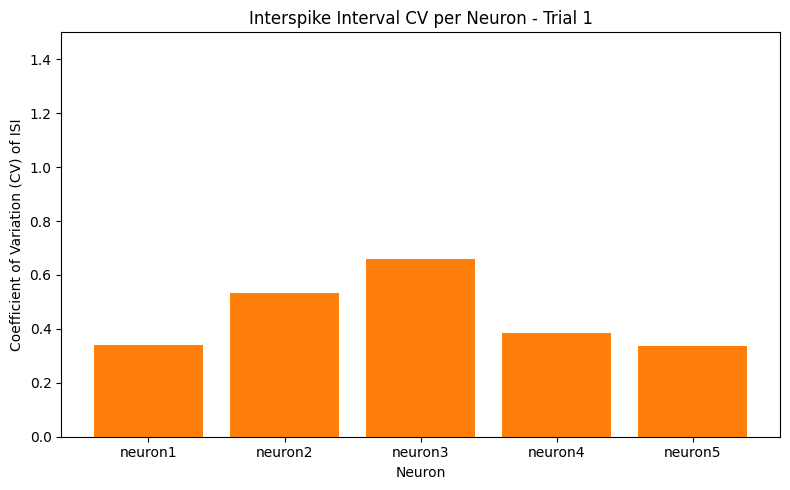

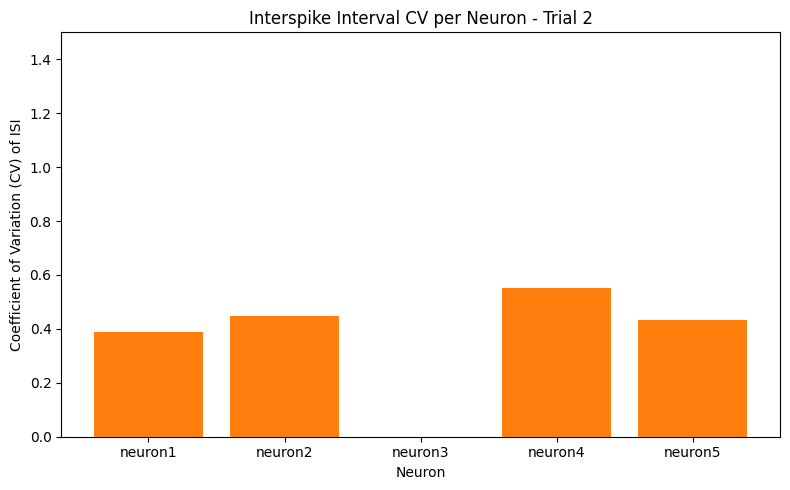

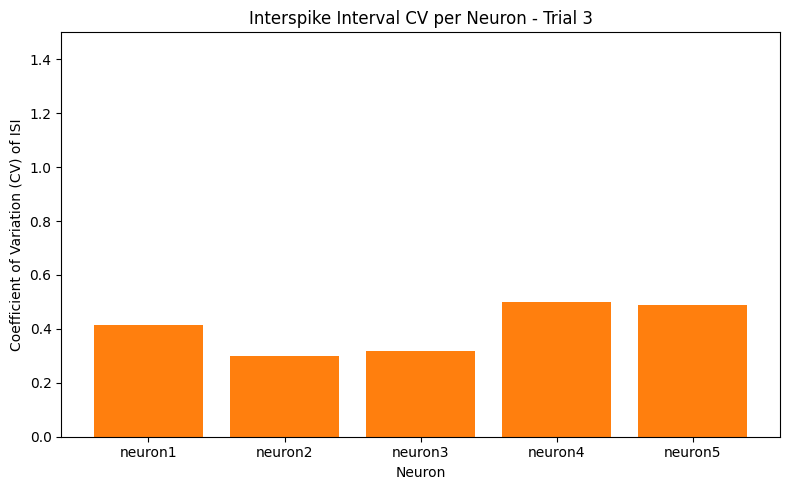

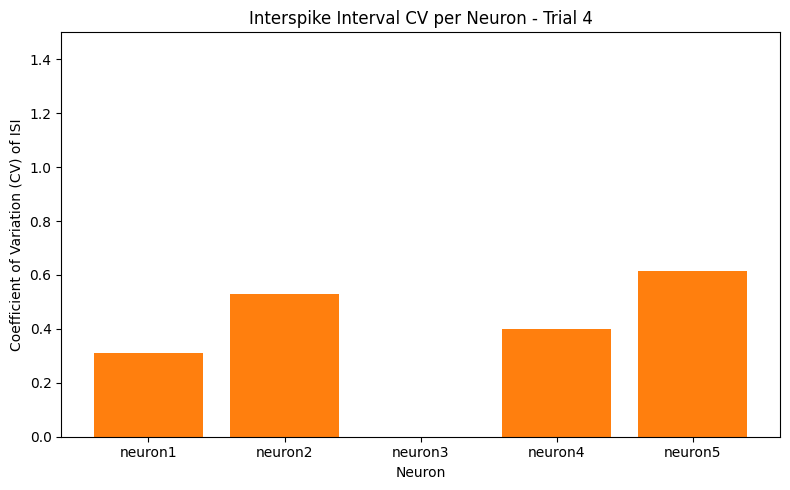

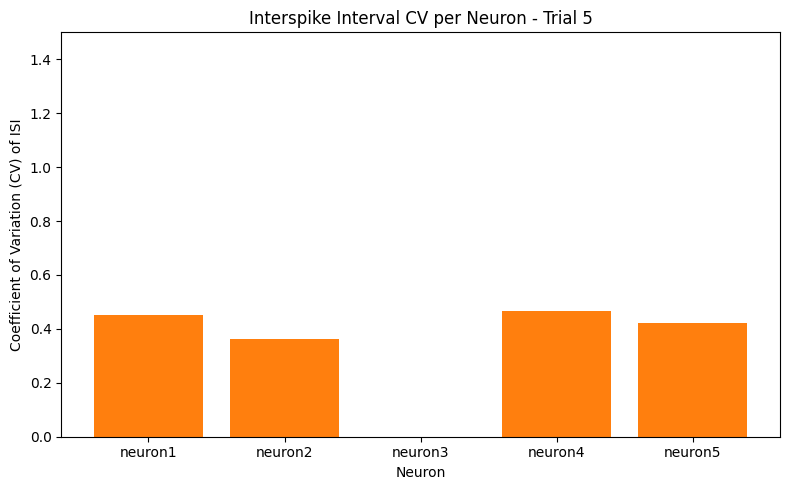

In [12]:
def compute_isi_cv(spike_train):
    spike_times = np.where(spike_train == 1)[0]
    if len(spike_times) < 2:
        return np.nan
    isis = np.diff(spike_times)
    if len(isis) == 0 or np.mean(isis) == 0:
        return np.nan
    return np.std(isis) / np.mean(isis)

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]
neuron_labels = [col.replace('_spike', '') for col in spike_columns]

for trial_idx, trial_df in enumerate(all_trials):
    cvs = []
    for col in spike_columns:
        cv = compute_isi_cv(trial_df[col].values)
        cvs.append(cv)
    plt.figure(figsize=(8, 5))
    plt.bar(neuron_labels, cvs, color='tab:orange')
    plt.ylabel('Coefficient of Variation (CV) of ISI')
    plt.xlabel('Neuron')
    plt.title(f'Interspike Interval CV per Neuron - Trial {trial_idx+1}')
    plt.ylim(0, max(1.5, np.nanmax(cvs) + 0.2))
    plt.tight_layout()
    plt.show()

Spike Rate.  This is a series of plots comparing the spike rate within a single trial.  

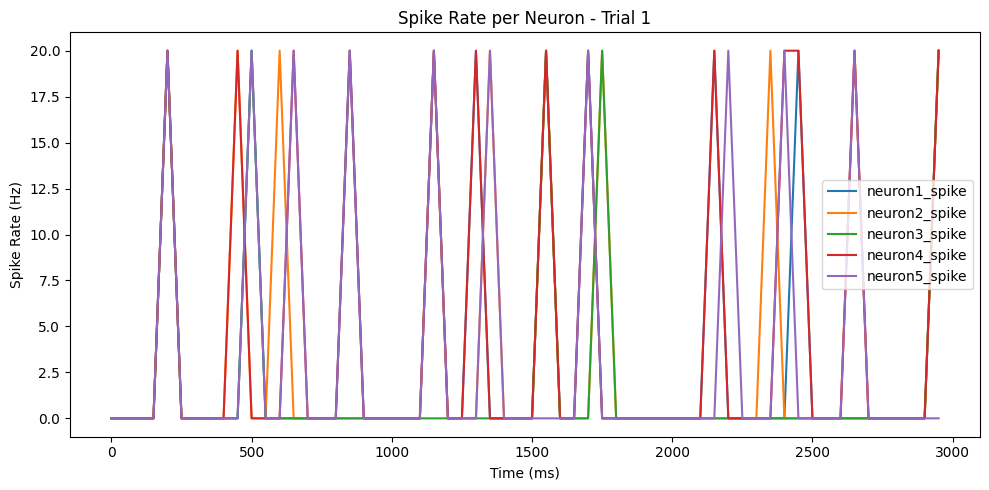

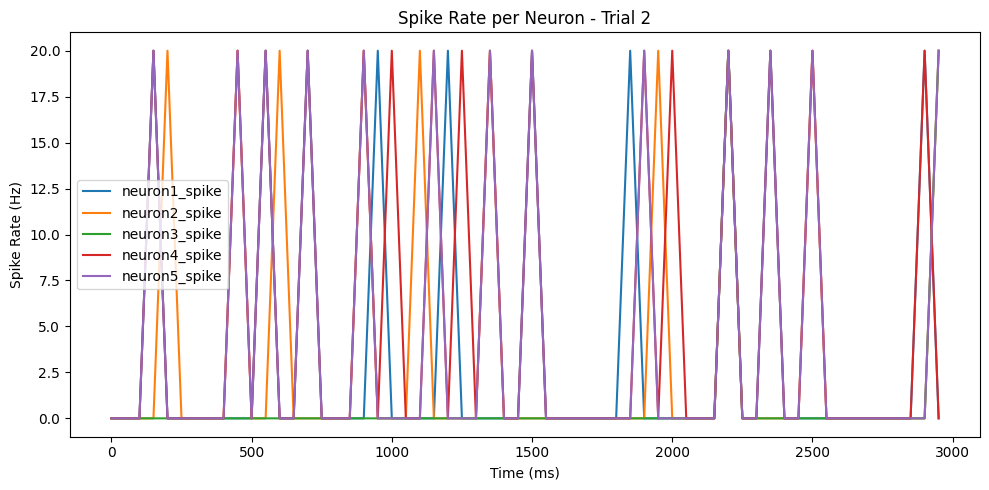

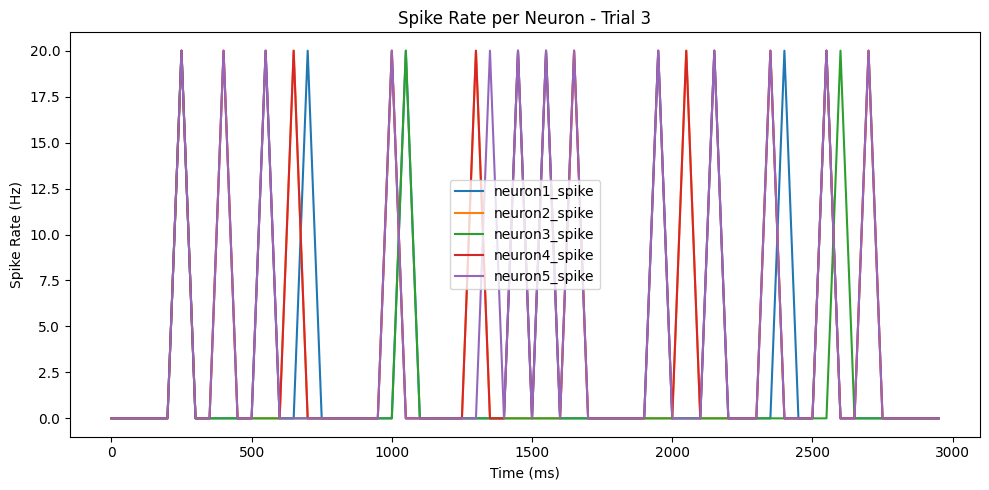

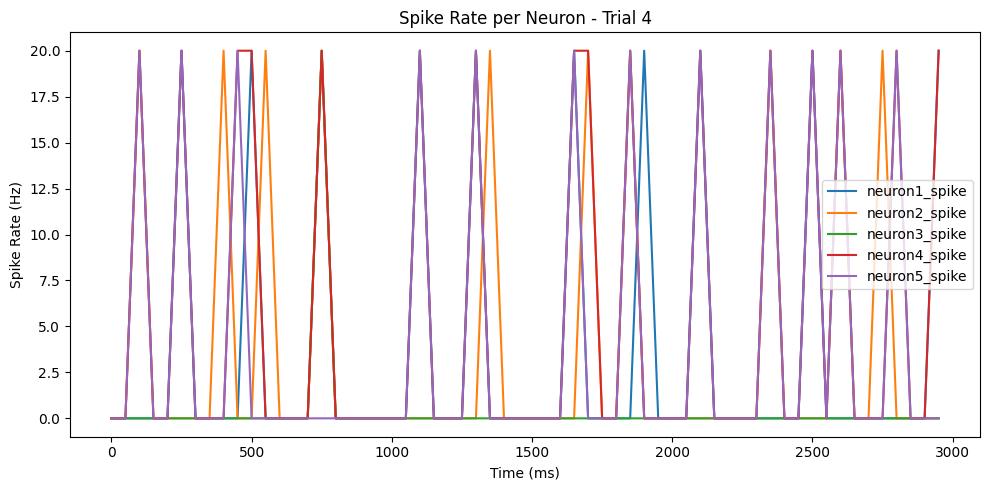

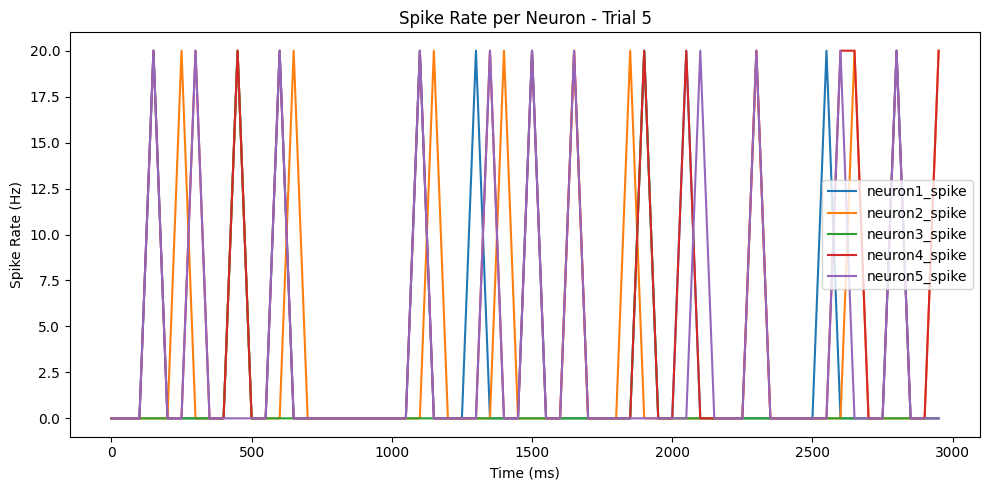

In [13]:
for trial_idx, trial_df in enumerate(all_trials):
    plt.figure(figsize=(10, 5))
    for n, col in enumerate(spike_columns):
        # Calculate spike rate in Hz for each bin
        spike_counts = binned_spikes[trial_idx, :, n]
        spike_rate_hz = spike_counts * (1000 / bin_size)  # bin_size in ms, so 1000/bin_size gives Hz
        plt.plot(time_bins, spike_rate_hz, label=col)
    plt.xlabel('Time (ms)')
    plt.ylabel('Spike Rate (Hz)')
    plt.title(f'Spike Rate per Neuron - Trial {trial_idx+1}')
    plt.legend()
    plt.tight_layout()
    plt.show()

Spike Rate.  This is a series of plots comparing the spike rate for the same neuron across different trials. 

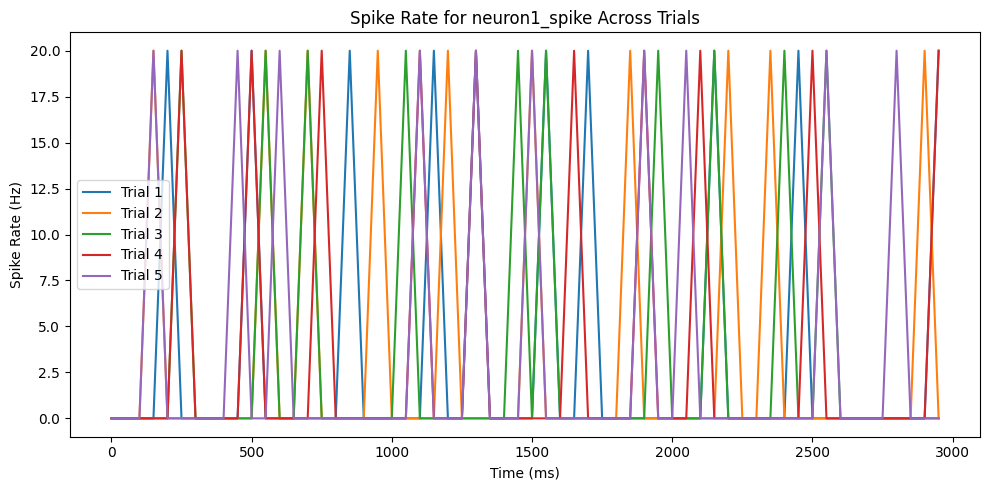

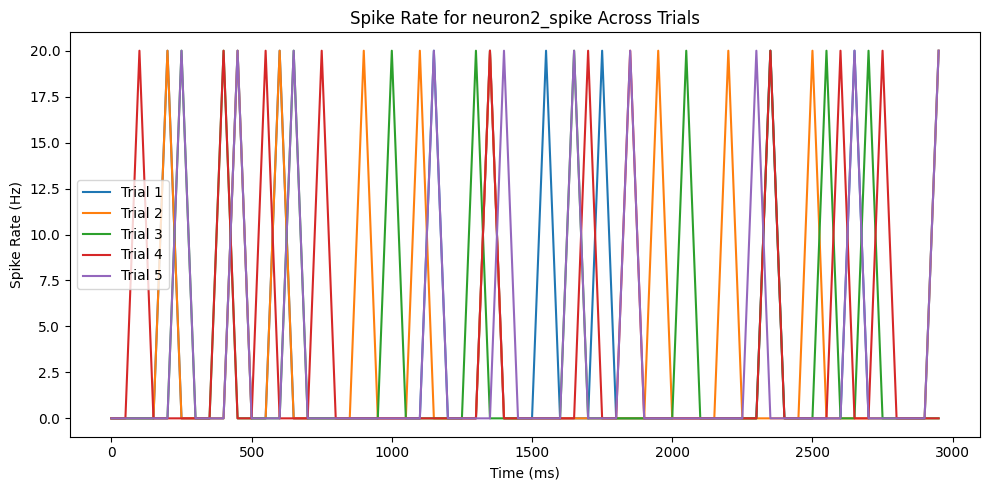

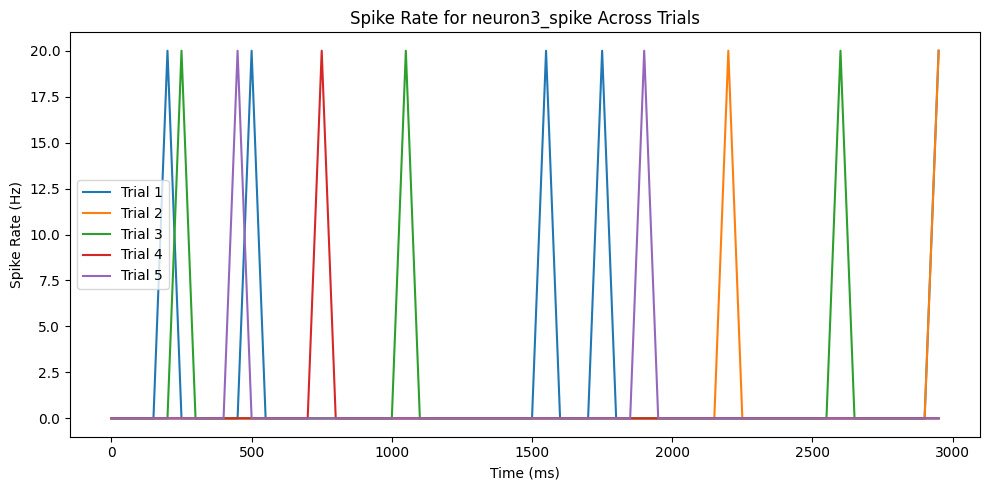

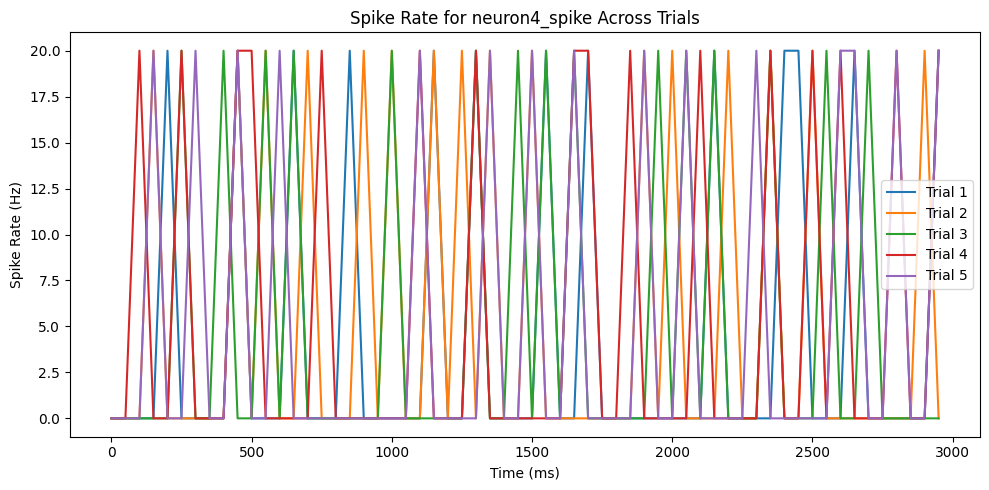

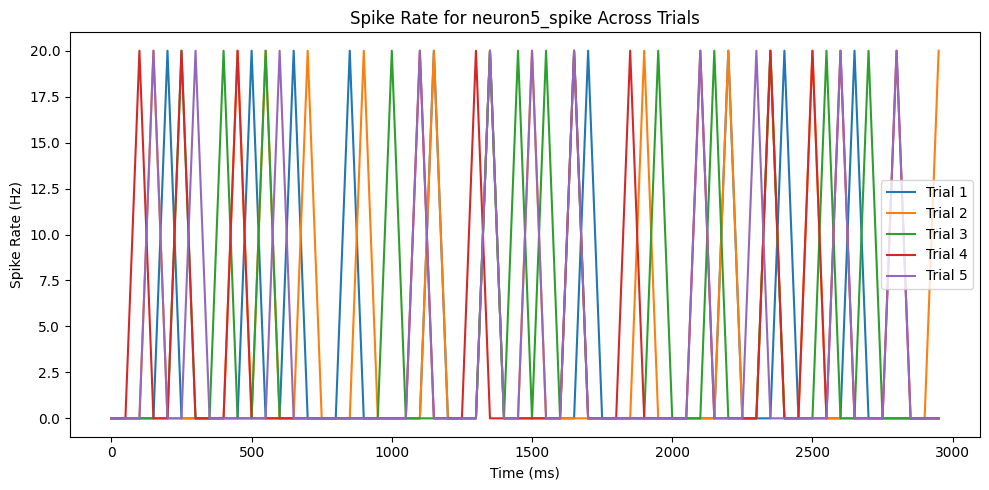

In [14]:
for n, col in enumerate(spike_columns):
    plt.figure(figsize=(10, 5))
    for trial_idx in range(NUM_TRIALS):
        spike_counts = binned_spikes[trial_idx, :, n]
        spike_rate_hz = spike_counts * (1000 / bin_size)
        plt.plot(time_bins, spike_rate_hz, label=f'Trial {trial_idx+1}')
    plt.xlabel('Time (ms)')
    plt.ylabel('Spike Rate (Hz)')
    plt.title(f'Spike Rate for {col} Across Trials')
    plt.legend()
    plt.tight_layout()
    plt.show()


Spike Rate plus Fano .  The above two series of charts are challenging to discern any useful information from.  

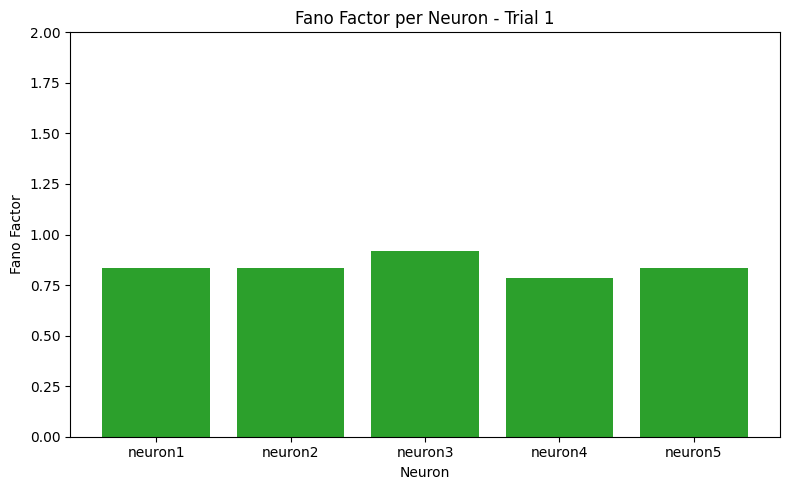

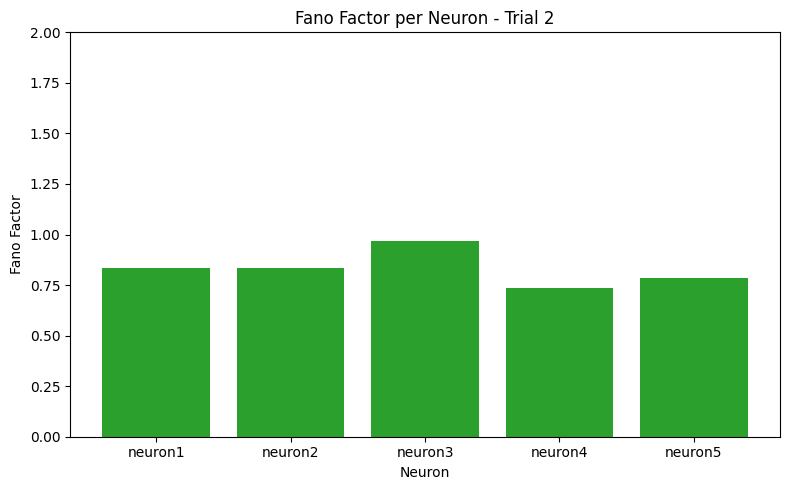

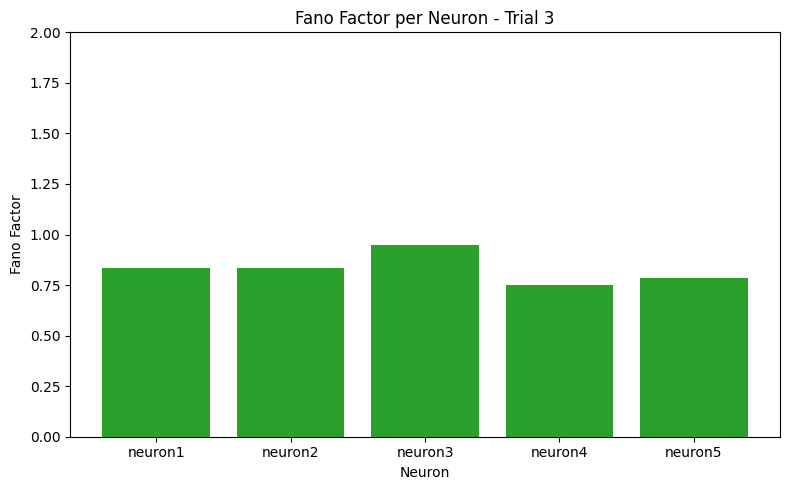

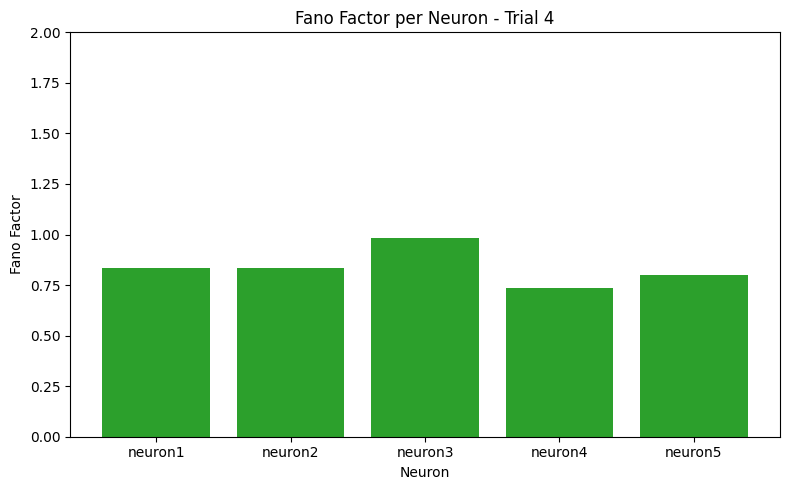

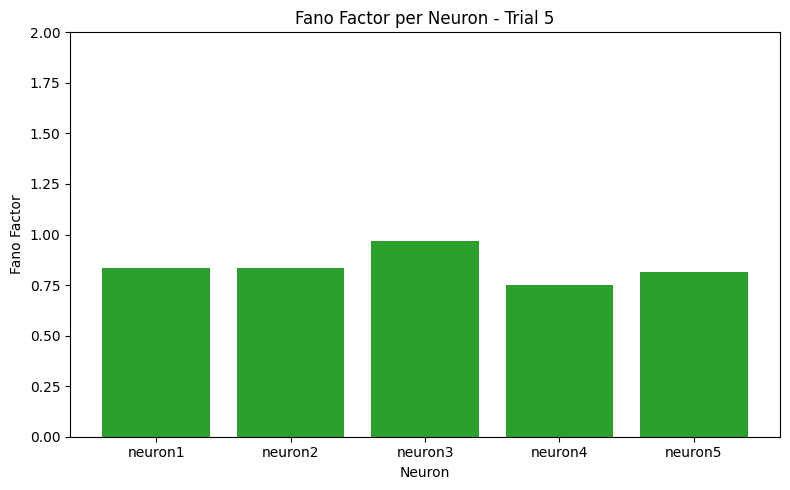

In [15]:
fano_factors = []
for trial_idx, trial_df in enumerate(all_trials):
    trial_fanos = []
    for n, col in enumerate(spike_columns):
        counts = binned_spikes[trial_idx, :, n]
        if np.mean(counts) == 0:
            fano = np.nan
        else:
            fano = np.var(counts) / np.mean(counts)
        trial_fanos.append(fano)
    fano_factors.append(trial_fanos)
    plt.figure(figsize=(8, 5))
    plt.bar(neuron_labels, trial_fanos, color='tab:green')
    plt.ylabel('Fano Factor')
    plt.xlabel('Neuron')
    plt.title(f'Fano Factor per Neuron - Trial {trial_idx+1}')
    plt.ylim(0, max(2, np.nanmax(trial_fanos) + 0.2))
    plt.tight_layout()
    plt.show()

The fano factor is a metric that helps us understand the variability in the firing.  Values less than 1 indicate a regular firing rate.   Values greater than 1 indicate a more irregular firing rate.  

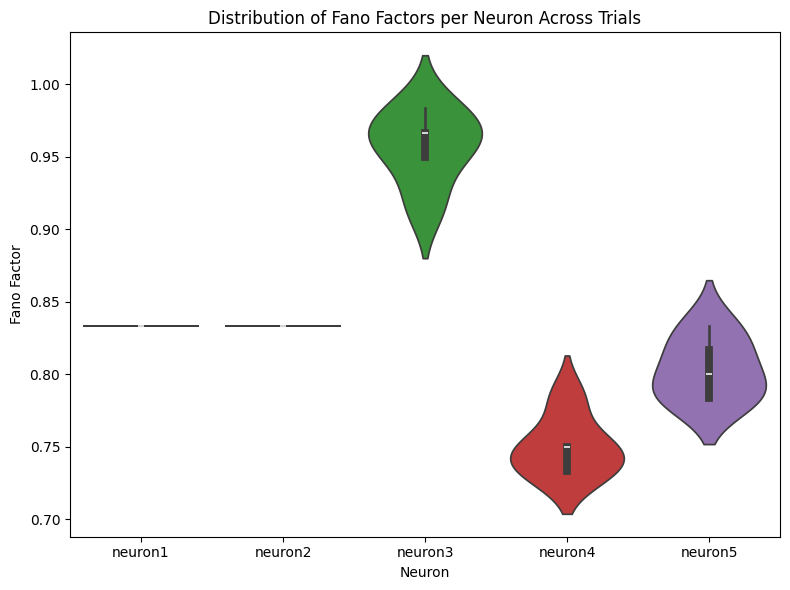

In [16]:
plt.figure(figsize=(8, 6))
fano_factors_array = np.array(fano_factors)
sns.violinplot(data=fano_factors_array, inner='box')
plt.xticks(ticks=np.arange(len(neuron_labels)), labels=neuron_labels)
plt.xlabel('Neuron')
plt.ylabel('Fano Factor')
plt.title('Distribution of Fano Factors per Neuron Across Trials')
plt.tight_layout()
plt.show()

Time Rescaling Theorem

Synchrony Ratio

# Spike Train Similarity Metrics

The first metric here is the victor purpura distance metric.  Here we are comparing the same neuron between different trials.  The data is output as a heatmap.  Lower values indicate more similarity.  In the heatmap, this is colors that are closer to purple.

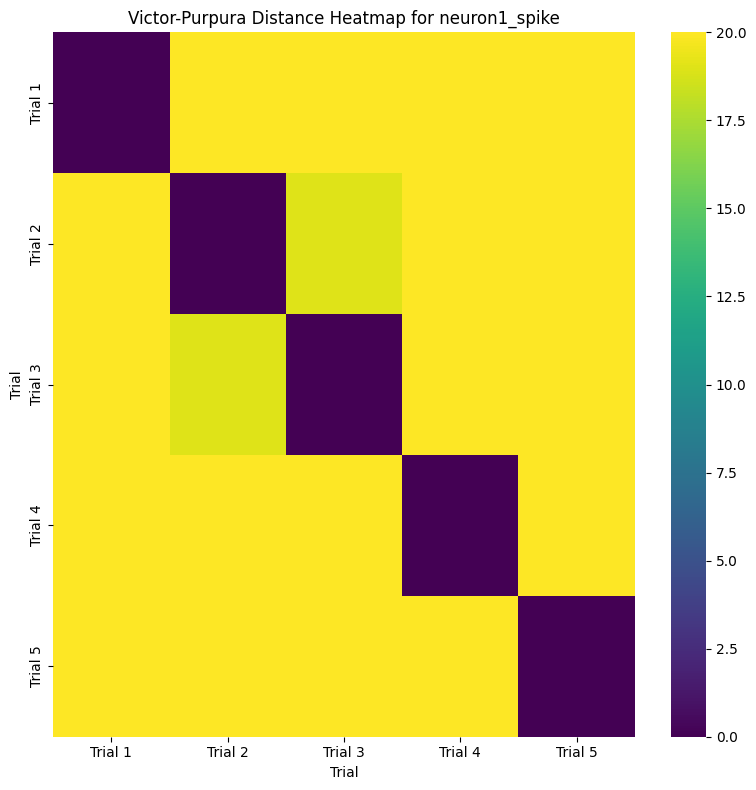

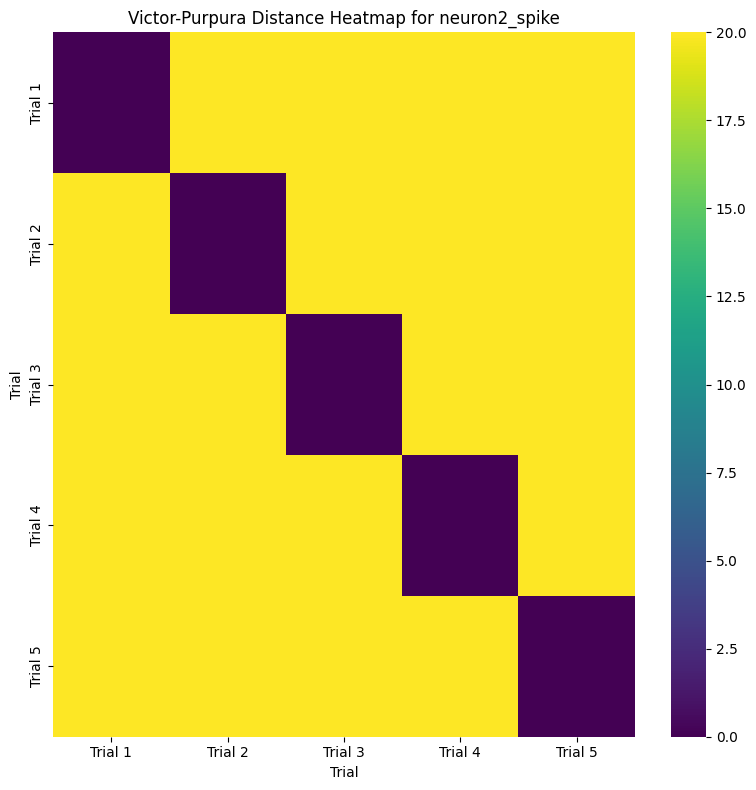

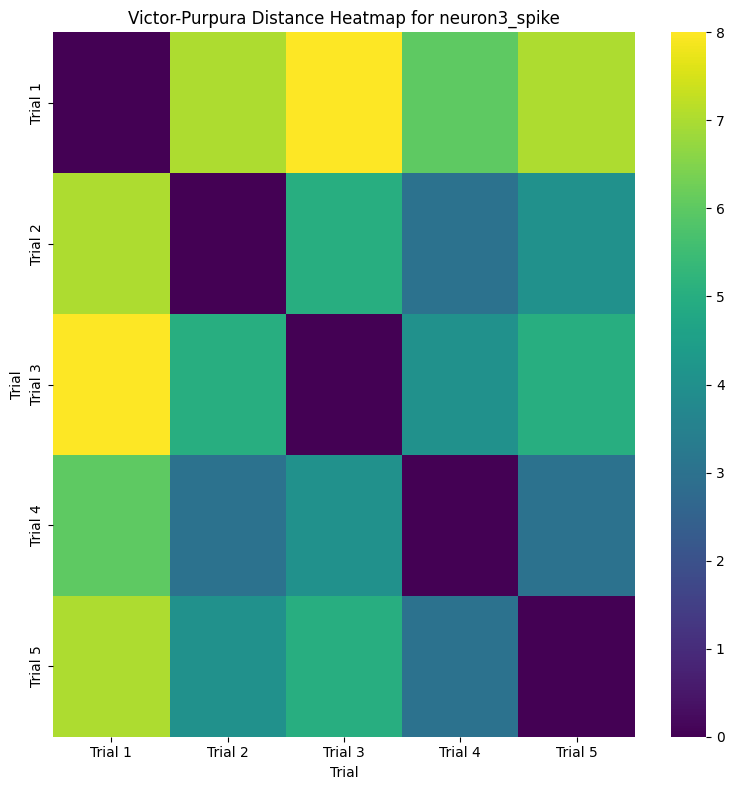

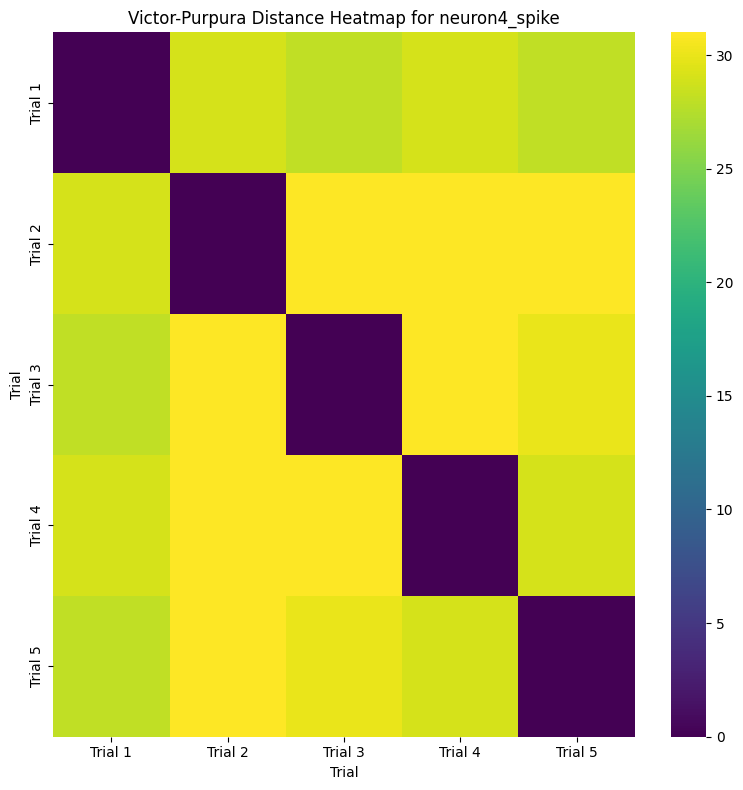

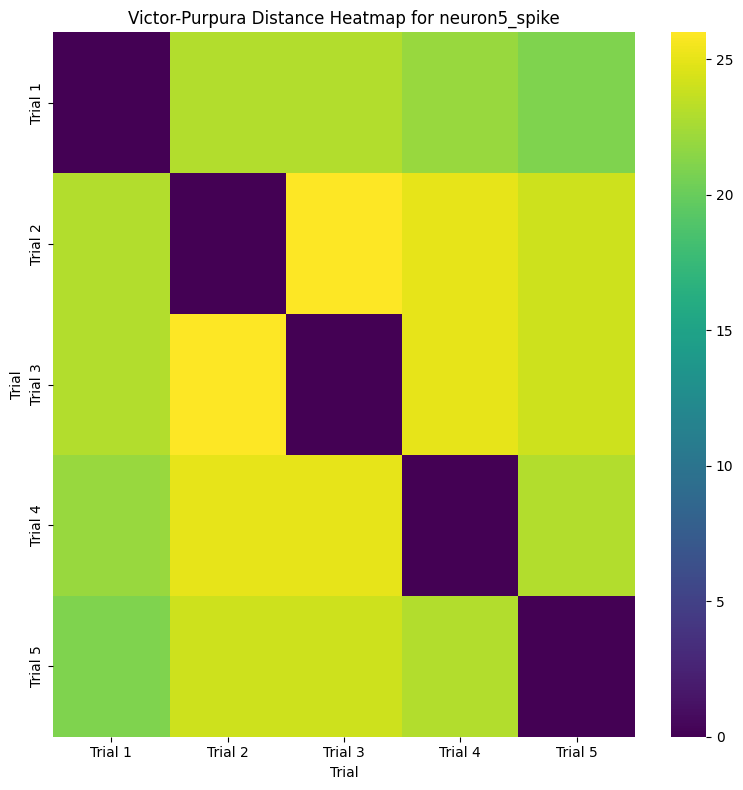

In [17]:

def victor_purpura_distance(trace1, trace2, q=1.0):
    spike_times1 = np.where(trace1 == 1)[0]
    spike_times2 = np.where(trace2 == 1)[0]
    n = len(spike_times1)
    m = len(spike_times2)
    dp = np.zeros((n+1, m+1))
    dp[:,0] = np.arange(n+1)
    dp[0,:] = np.arange(m+1)
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = q * abs(spike_times1[i-1] - spike_times2[j-1])
            dp[i,j] = min(
                dp[i-1,j] + 1,
                dp[i,j-1] + 1,
                dp[i-1,j-1] + cost
            )
    return dp[n,m]

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]

vp_distances = {}
for neuron in spike_columns:
    vp_distances[neuron] = []
    for i in range(len(all_trials)):
        for j in range(i+1, len(all_trials)):
            d = victor_purpura_distance(
                all_trials[i][neuron].values, 
                all_trials[j][neuron].values, 
                q=1.0
            )
            vp_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})


for neuron in spike_columns:
    distances = vp_distances[neuron]
    trial_numbers = sorted(set([pair['trial_pair'][0] for pair in distances] + [pair['trial_pair'][1] for pair in distances]))
    n_trials = max(trial_numbers)
    vp_matrix = np.zeros((n_trials, n_trials))
    vp_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vp_matrix[i-1, j-1] = entry['distance']
        vp_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vp_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vp_matrix, annot=False, cmap='viridis', 
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)], 
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Victor-Purpura Distance Heatmap for {neuron}')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()


Van Rossum Metric

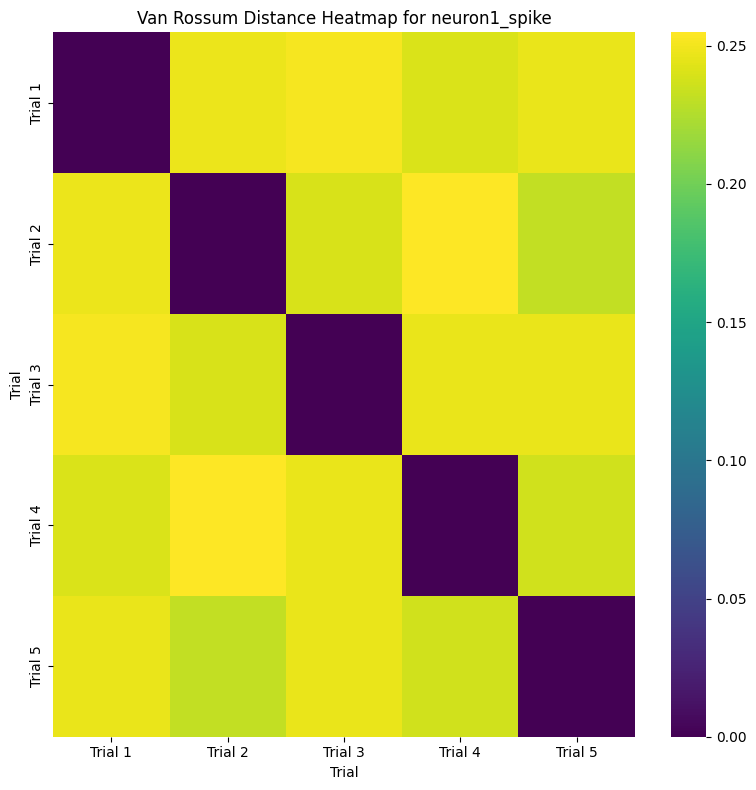

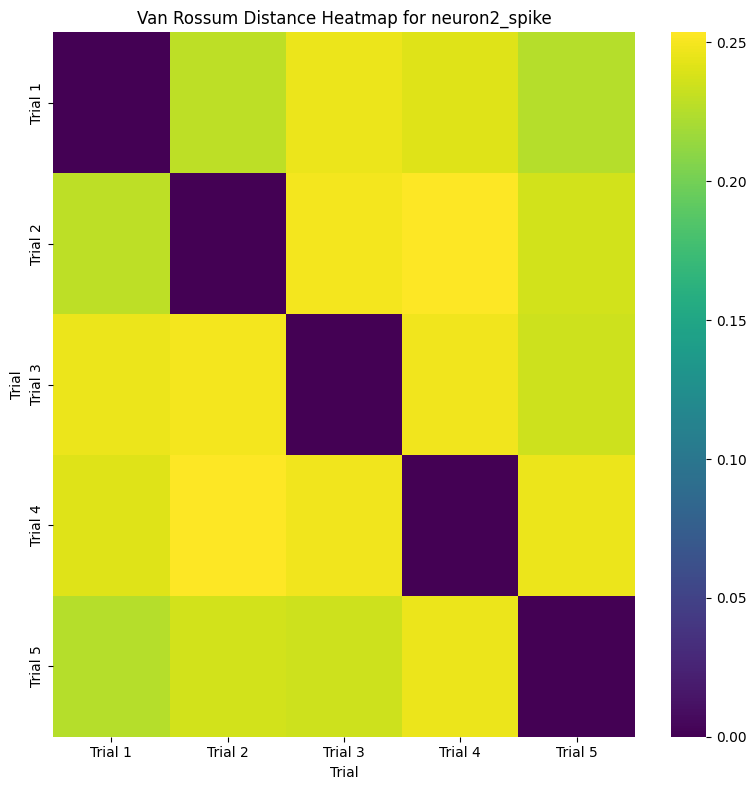

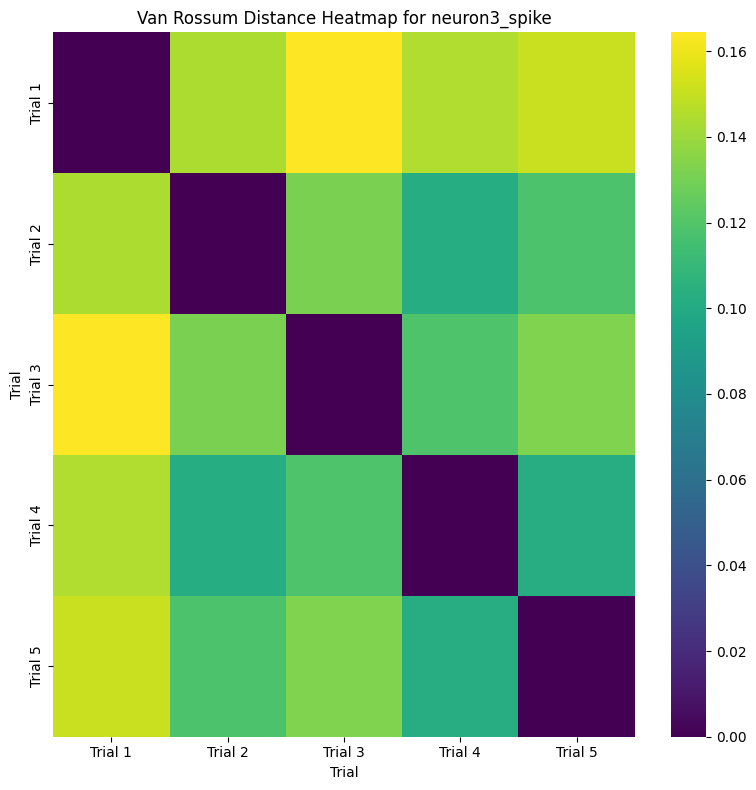

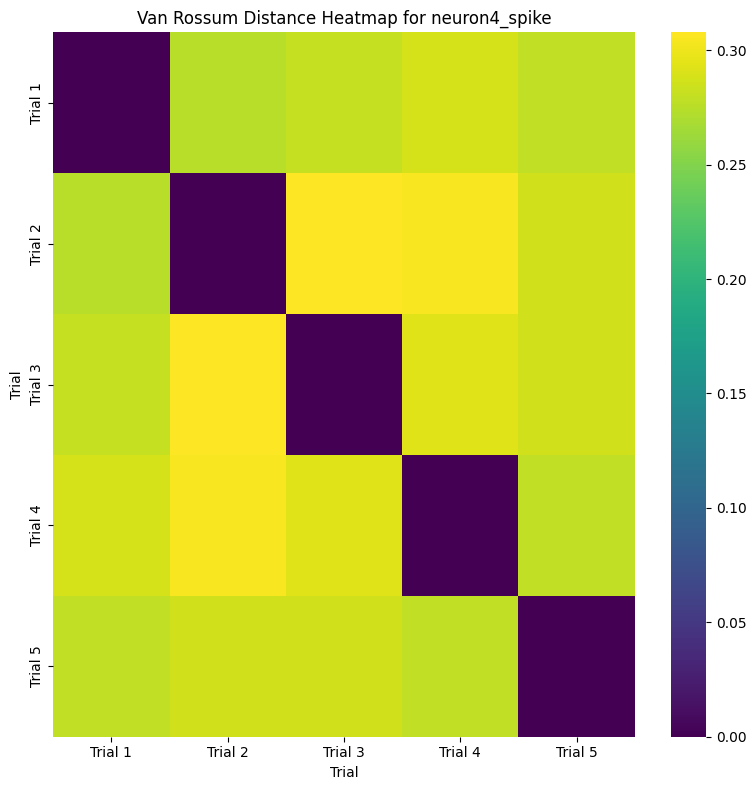

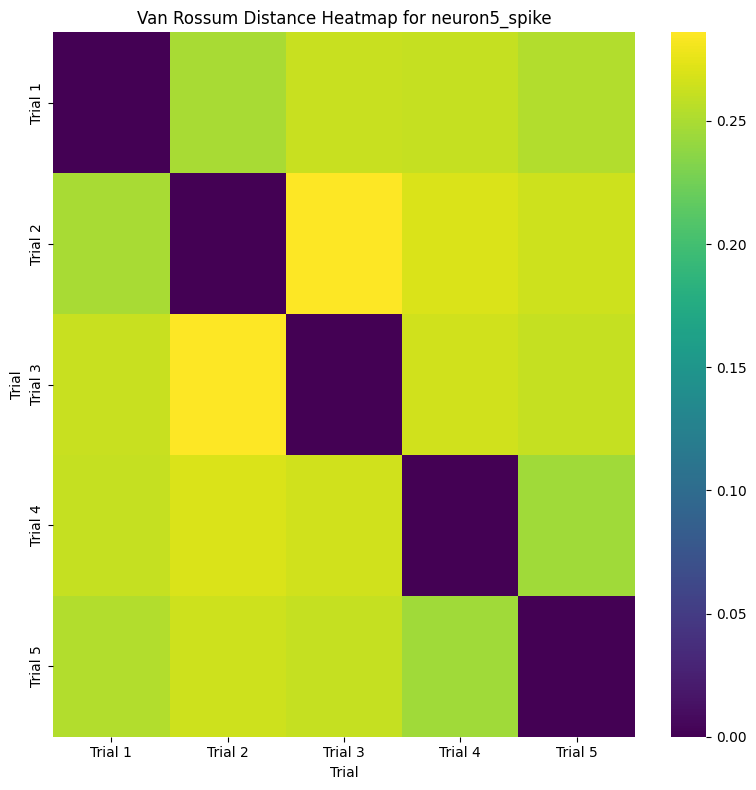

In [20]:
def van_rossum_distance(trace1, trace2, tau=20.0):
    # Convolve spike trains with exponential kernel
    t = np.arange(len(trace1))
    kernel = np.exp(-t / tau)
    conv1 = np.convolve(trace1, kernel, mode='full')[:len(trace1)]
    conv2 = np.convolve(trace2, kernel, mode='full')[:len(trace2)]
    return np.sqrt(np.sum((conv1 - conv2) ** 2) / len(trace1))

van_rossum_distances = {}
tau = 20.0  # ms, can be adjusted

for neuron in spike_columns:
    van_rossum_distances[neuron] = []
    for i in range(NUM_TRIALS):
        for j in range(i+1, NUM_TRIALS):
            d = van_rossum_distance(
                all_trials[i][neuron].values,
                all_trials[j][neuron].values,
                tau=tau
            )
            van_rossum_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})

for neuron in spike_columns:
    distances = van_rossum_distances[neuron]
    n_trials = NUM_TRIALS
    vr_matrix = np.zeros((n_trials, n_trials))
    vr_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vr_matrix[i-1, j-1] = entry['distance']
        vr_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vr_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vr_matrix, annot=False, cmap='viridis',
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)],
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Van Rossum Distance Heatmap for {neuron}')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()

Schrieber Similarity Metric

# Finding Correlations


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0338  , p=0.8542  , df_denom=2996, df_num=1
ssr based chi2 test:   chi2=0.0338  , p=0.8541  , df=1
likelihood ratio test: chi2=0.0338  , p=0.8541  , df=1
parameter F test:         F=0.0338  , p=0.8542  , df_denom=2996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=14.2189 , p=0.0000  , df_denom=2993, df_num=2
ssr based chi2 test:   chi2=28.4852 , p=0.0000  , df=2
likelihood ratio test: chi2=28.3508 , p=0.0000  , df=2
parameter F test:         F=14.2189 , p=0.0000  , df_denom=2993, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.4754  , p=0.0000  , df_denom=2990, df_num=3
ssr based chi2 test:   chi2=28.4927 , p=0.0000  , df=3
likelihood ratio test: chi2=28.3581 , p=0.0000  , df=3
parameter F test:         F=9.4754  , p=0.0000  , df_denom=2990, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=7.1037  , p=0.

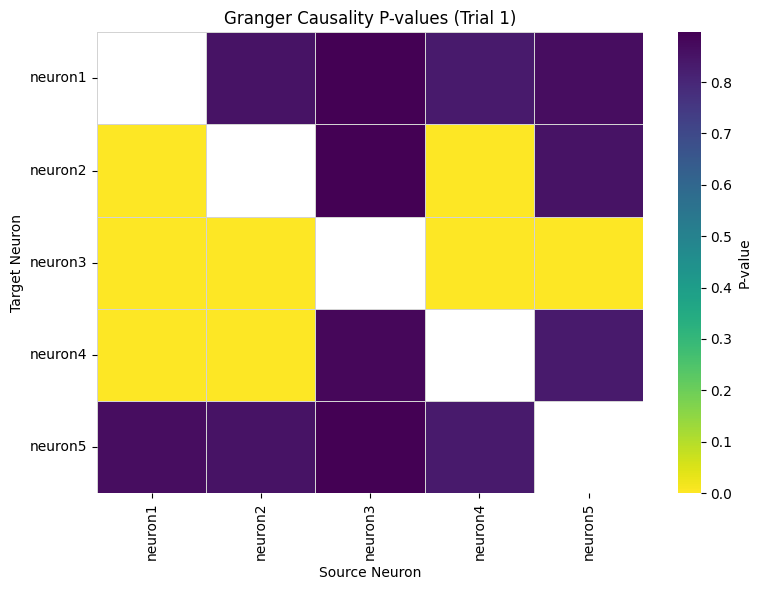

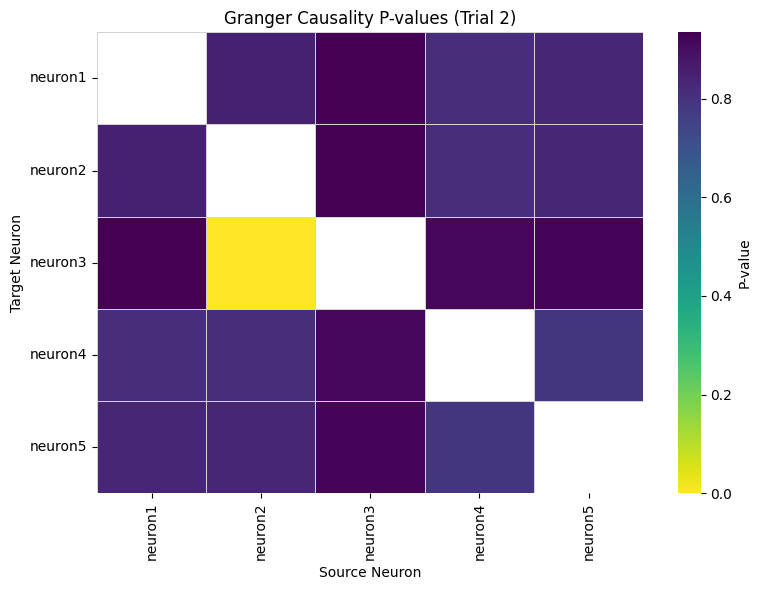

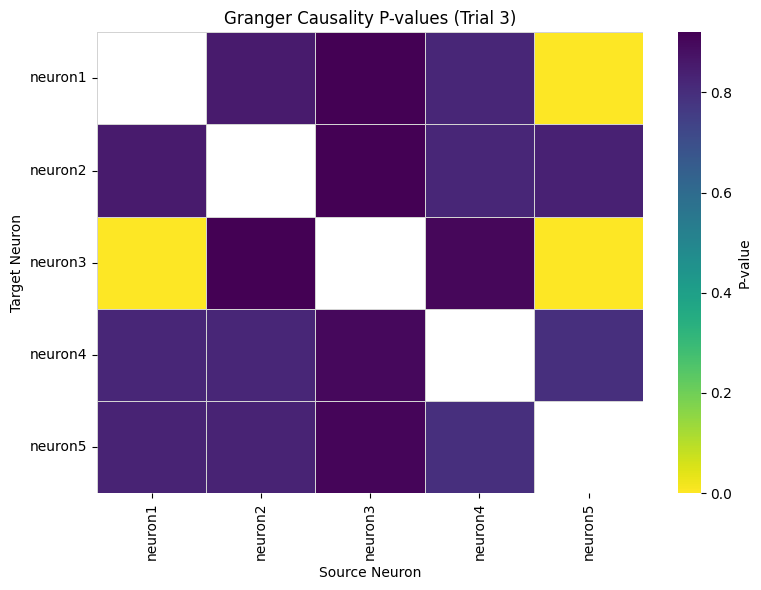

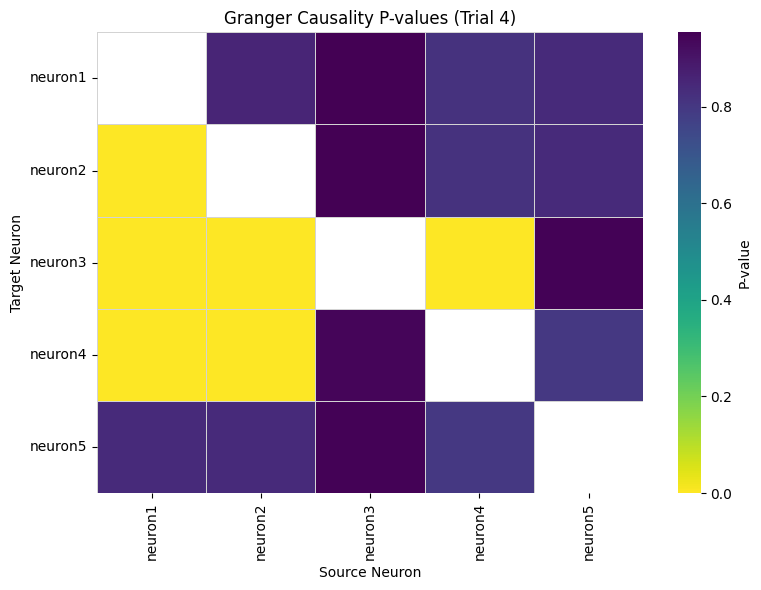

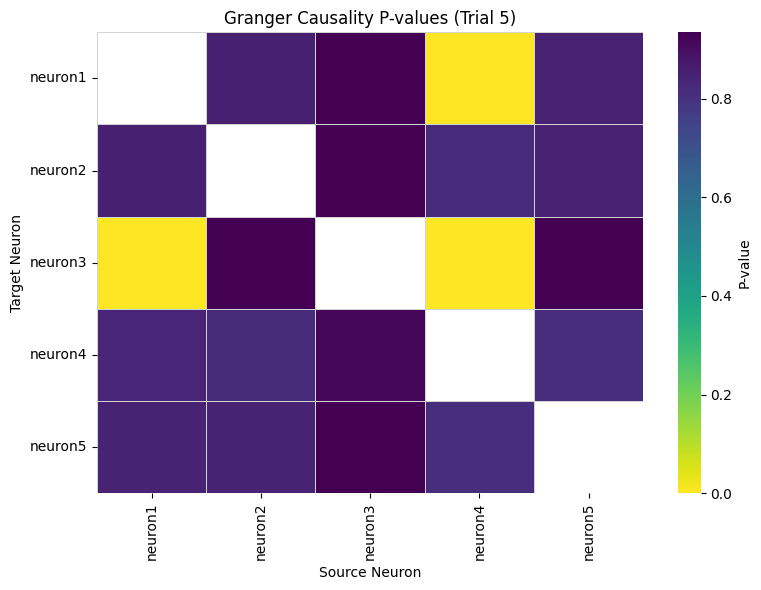

In [18]:
max_lag = 5
spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]
neuron_names = [col.replace('_spike', '') for col in spike_columns]
neuron_to_idx = {name: idx for idx, name in enumerate(neuron_names)}
num_neurons = len(spike_columns)

for trial_num in range(NUM_TRIALS):
    df = all_trials[trial_num]
    granger_results = {}
    for source_idx, source_spike in enumerate(spike_columns):
        for target_idx, target_spike in enumerate(spike_columns):
            if source_idx == target_idx:
                continue
            source = source_spike.replace('_spike', '')
            target = target_spike.replace('_spike', '')
            key = (source, target)
            try:
                data = df[[target_spike, source_spike]].astype(float).values
                test_result = grangercausalitytests(data, maxlag=max_lag)
                min_pvalue = min([test_result[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag+1)])
                granger_results[key] = min_pvalue
            except Exception:
                granger_results[key] = np.nan
    globals()[f"granger_results_trial{trial_num+1}"] = granger_results

for trial_num in range(NUM_TRIALS):
    granger_results = globals()[f"granger_results_trial{trial_num+1}"]
    p_values_matrix = np.full((num_neurons, num_neurons), np.nan)
    for (source, target), p_value in granger_results.items():
        if source in neuron_to_idx and target in neuron_to_idx:
            source_idx = neuron_to_idx[source]
            target_idx = neuron_to_idx[target]
            p_values_matrix[target_idx, source_idx] = p_value
    granger_df = pd.DataFrame(p_values_matrix, index=neuron_names, columns=neuron_names)
    if np.isnan(granger_df.values).all():
        print(f"No valid Granger causality p-values for trial {trial_num+1}.")
        continue
    plt.figure(figsize=(8, 6))
    sns.heatmap(granger_df, cmap='viridis_r', annot=False, fmt=".2f",
                linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'P-value'})
    plt.title(f'Granger Causality P-values (Trial {trial_num+1})')
    plt.xlabel('Source Neuron')
    plt.ylabel('Target Neuron')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


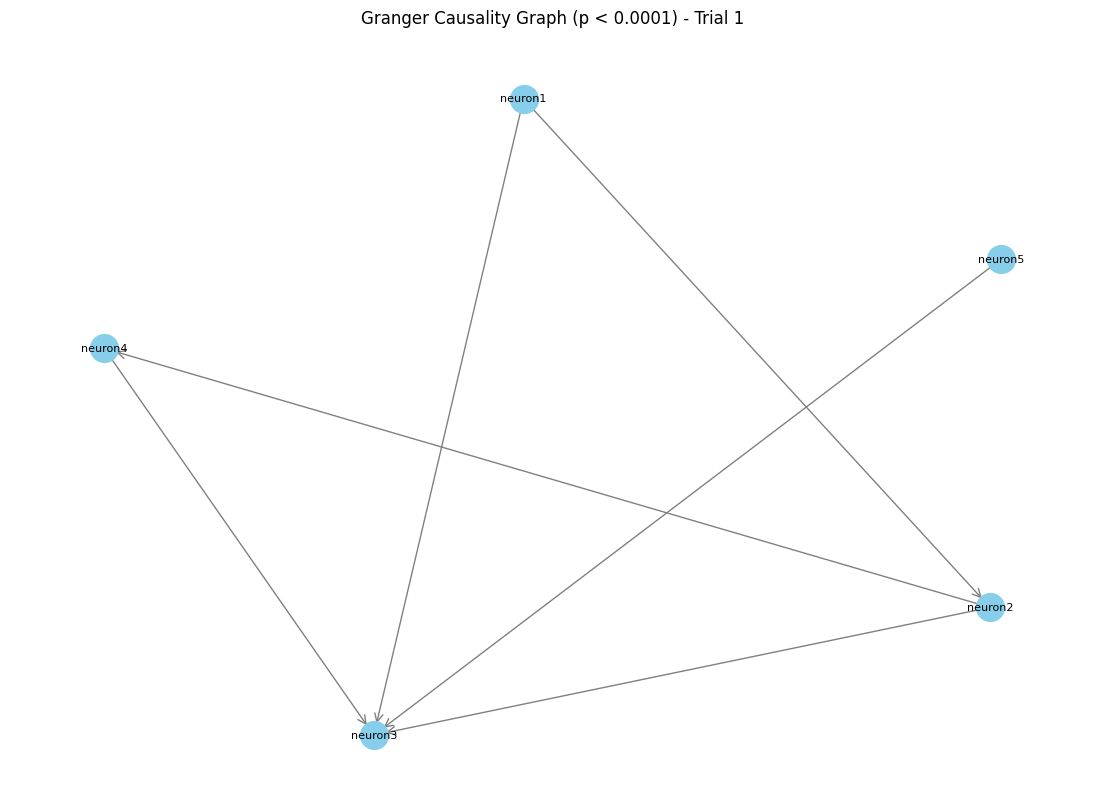

In [19]:
threshold = 0.0001

for trial_num in range(1, 2):
    granger_df = None
    granger_results = globals()[f"granger_results_trial{trial_num}"]
    p_values_matrix = np.full((num_neurons, num_neurons), np.nan)
    for (source, target), p_value in granger_results.items():
        target_idx = neuron_to_idx[target]
        source_idx = neuron_to_idx[source]
        p_values_matrix[target_idx, source_idx] = p_value
    granger_df = pd.DataFrame(p_values_matrix, index=neuron_names, columns=neuron_names)

    G = nx.DiGraph()
    G.add_nodes_from(granger_df.columns)

    for source in granger_df.columns:
        for target in granger_df.index:
            p_value = granger_df.loc[target, source]
            if not np.isnan(p_value) and p_value < threshold:
                G.add_edge(source, target, weight=p_value)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=400, node_color='skyblue')
    nx.draw_networkx_labels(G, pos, font_size=8)
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
    plt.title(f'Granger Causality Graph (p < {threshold}) - Trial {trial_num}')
    plt.axis('off')
    plt.show()

Cross Correlation